In [ ]:
import pandas_datareader.data as web
import datetime
import pandas as pd

import yfinance as yf

data = yf.download(
    "WMT",
    start="2000-01-01",
    end="2025-01-19",
    auto_adjust=True
)

data

In [ ]:
data.columns = data.columns.droplevel(1)

In [ ]:
data = data.reset_index()

In [ ]:
data

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

sdf = spark.createDataFrame(data)

In [ ]:
sdf

In [ ]:
sdf.count()

In [ ]:
sdf.show(5000)

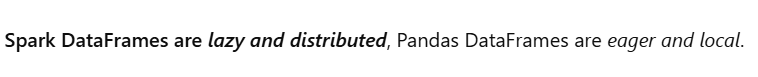

In [ ]:
sdf

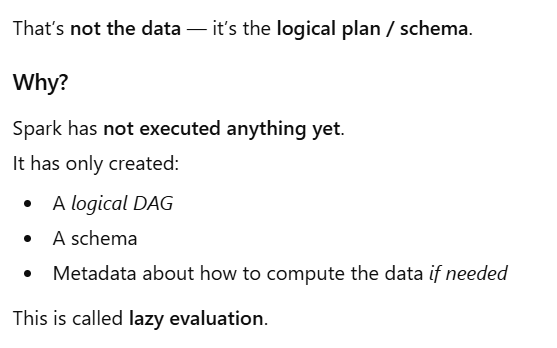

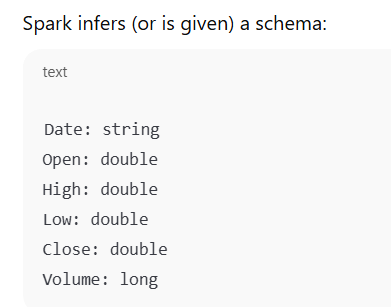

In [ ]:
sdf2 = sdf.filter(sdf.Close > 40)

In [ ]:
sdf2

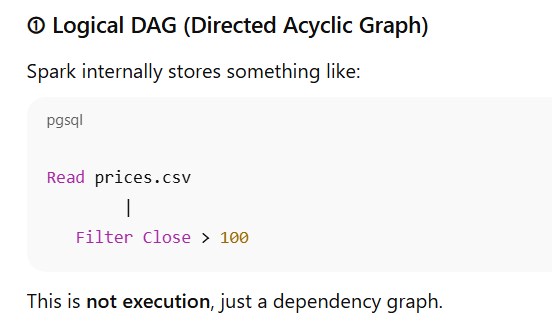

In [ ]:
sdf3 = sdf2.withColumn("day_diff", sdf2.Close -sdf2.Open)

In [ ]:
sdf3

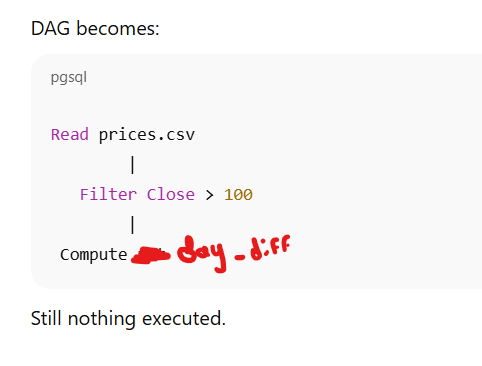

In [ ]:
sdf3.show()

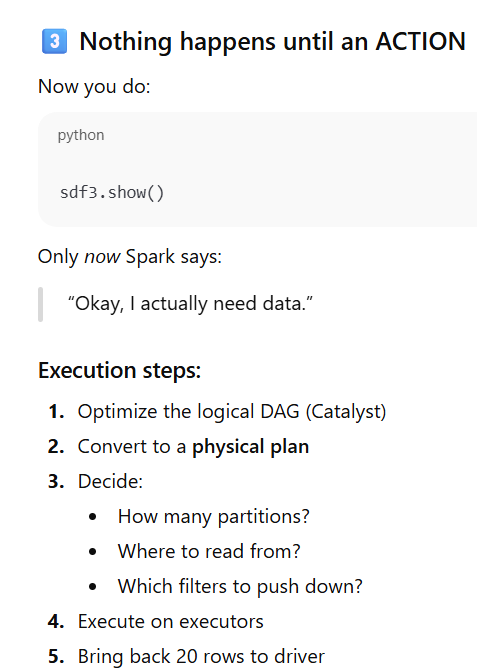

In [ ]:
sdf.columns

In [ ]:
sdf.printSchema()

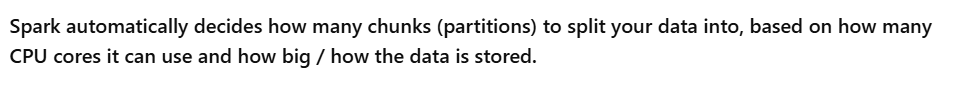

In [ ]:
sdf.rdd.getNumPartitions()

In [ ]:
spark.sparkContext.defaultParallelism

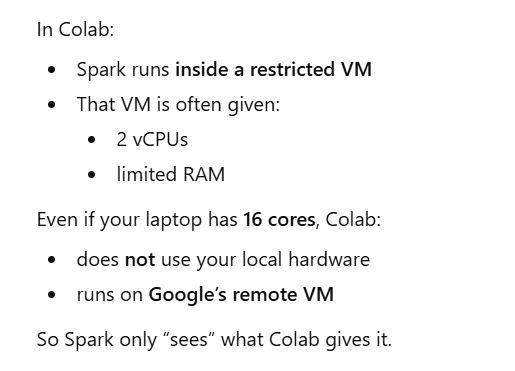

In [ ]:
sdf = sdf.repartition(8)

In [ ]:
sdf.rdd.getNumPartitions()

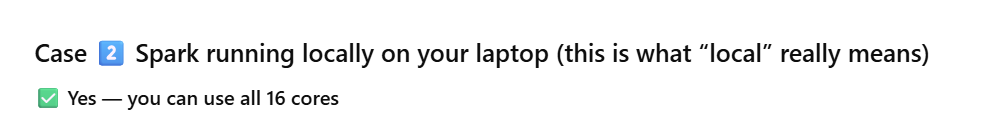

In [ ]:
sdf

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

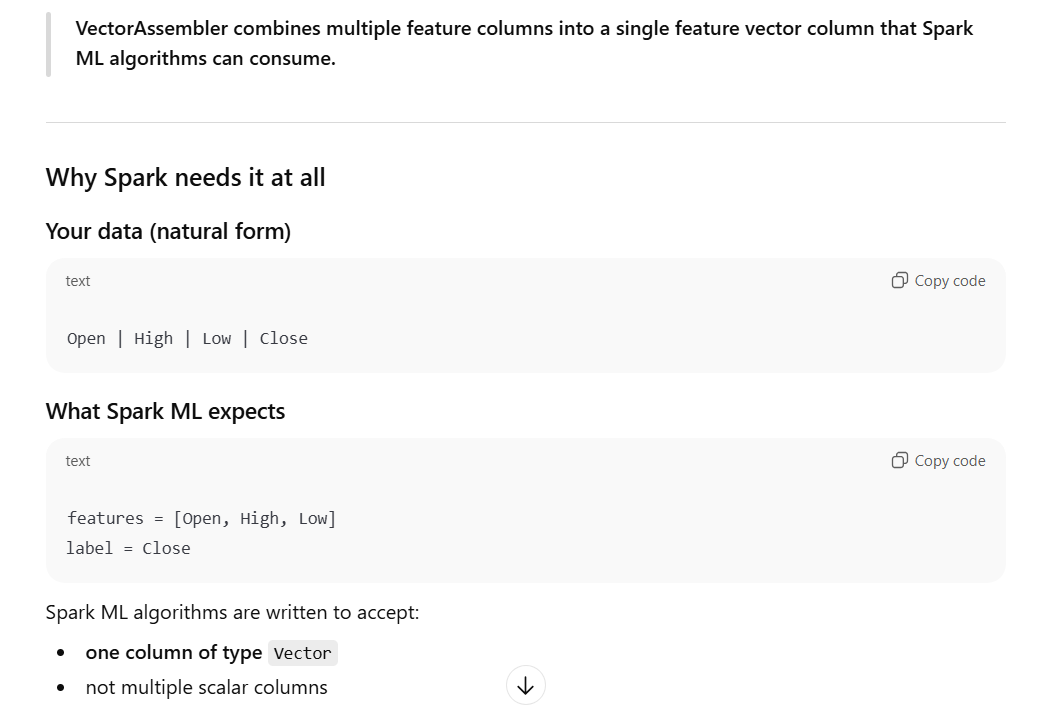

In [ ]:
train_df, test_df = sdf.randomSplit([0.8, 0.2], seed=2)

In [ ]:
assembler = VectorAssembler(
    inputCols=["Open", "High", "Low"],
    outputCol="features"
)

In [ ]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="Close",
    numTrees=100,
    maxDepth=5
)

In [ ]:
pipeline = Pipeline(stages=[assembler, rf])

In [ ]:
model = pipeline.fit(train_df)

In [ ]:
predictions = model.transform(test_df)

In [ ]:
predictions

In [ ]:
evaluator = RegressionEvaluator(
    labelCol="Close",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)
print("RMSE:", rmse)

In [ ]:
import pandas as pd
import numpy as np
import pyspark.pandas as ps
from pyspark.sql import SparkSession

In [ ]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [ ]:
df = ps.DataFrame(sdf)

In [ ]:
len(df)

In [ ]:
df #df.show() equivalent

In [ ]:
df[df['Close']>50]

In [ ]:
df.groupby('Close').mean()